# Ising Model: Metropolis Equilibration and Phase Transition

Two-dimensional Ising simulations across temperature and external field, transient removal, and magnetization and energy measurements.

Computational physics coursework by Udayan Sharma. Original code comments and saved outputs are retained. See the repository README for execution notes.


Exact 2D Ising critical temperature Tc ≈ 2.26919


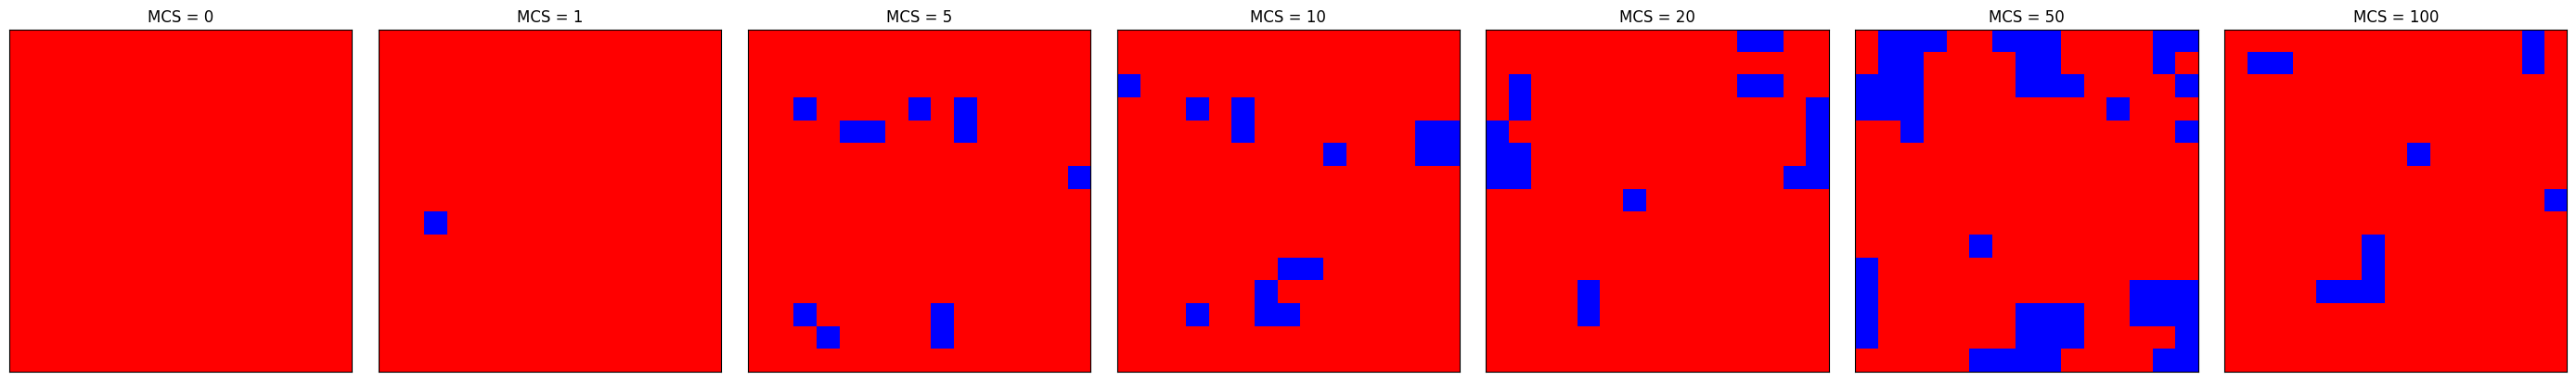

N=50, T=1.500, H=0.000, ic=up, MCS=500 | final m=0.9832, final E=-1.9360 | tail <m>=0.9867, tail <E>=-1.9512
N=50, T=2.000, H=0.000, ic=up, MCS=500 | final m=0.9256, final E=-1.7728 | tail <m>=0.9092, tail <E>=-1.7373
N=50, T=2.200, H=0.000, ic=up, MCS=2000 | final m=0.7864, final E=-1.5104 | tail <m>=0.7823, tail <E>=-1.5420
N=50, T=2.270, H=0.000, ic=up, MCS=2000 | final m=0.4208, final E=-1.3072 | tail <m>=0.4783, tail <E>=-1.3712
N=50, T=2.400, H=0.000, ic=up, MCS=1000 | final m=-0.2200, final E=-1.2144 | tail <m>=-0.0199, tail <E>=-1.1901
N=50, T=3.000, H=0.000, ic=up, MCS=500 | final m=-0.0496, final E=-0.8448 | tail <m>=0.0078, tail <E>=-0.8213
N=50, T=1.500, H=0.200, ic=up, MCS=500 | final m=0.9888, final E=-2.1530 | tail <m>=0.9906, tail <E>=-2.1631
N=50, T=2.000, H=0.200, ic=up, MCS=500 | final m=0.9584, final E=-2.0397 | tail <m>=0.9467, tail <E>=-2.0114
N=50, T=2.200, H=0.200, ic=up, MCS=2000 | final m=0.9032, final E=-1.8926 | tail <m>=0.9081, tail <E>=-1.9001
N=50, T=2.27

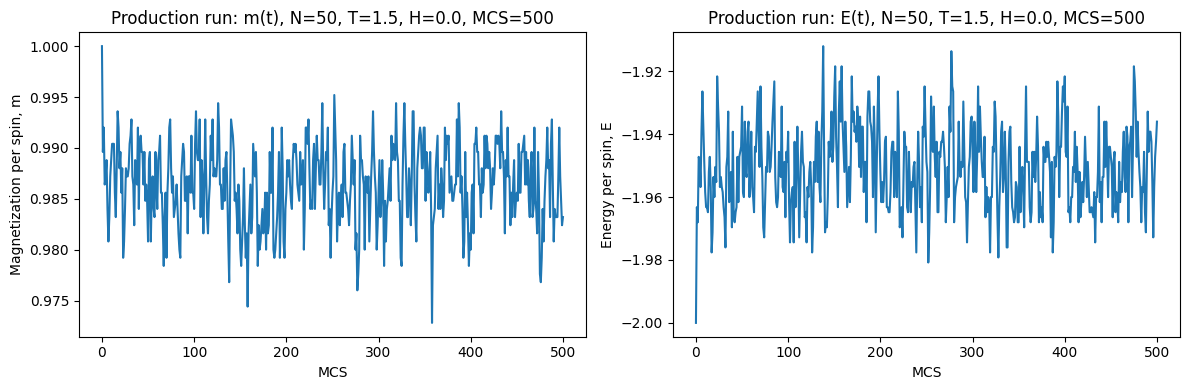

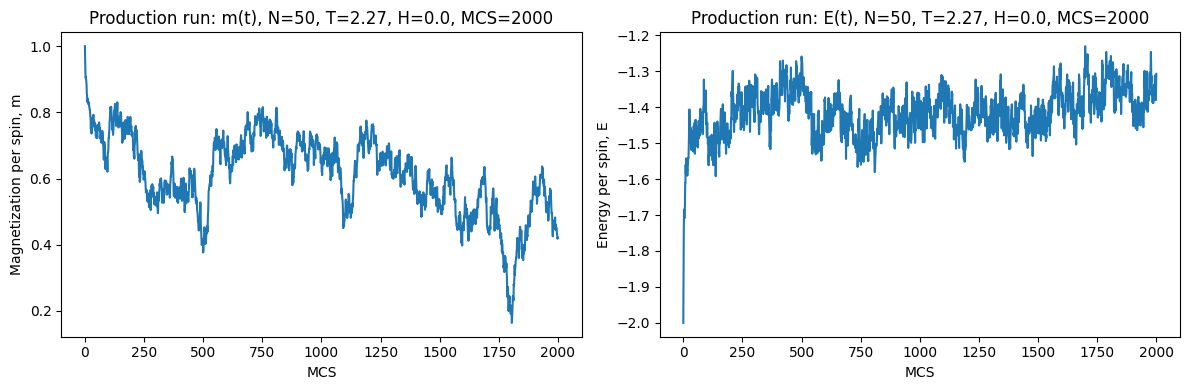

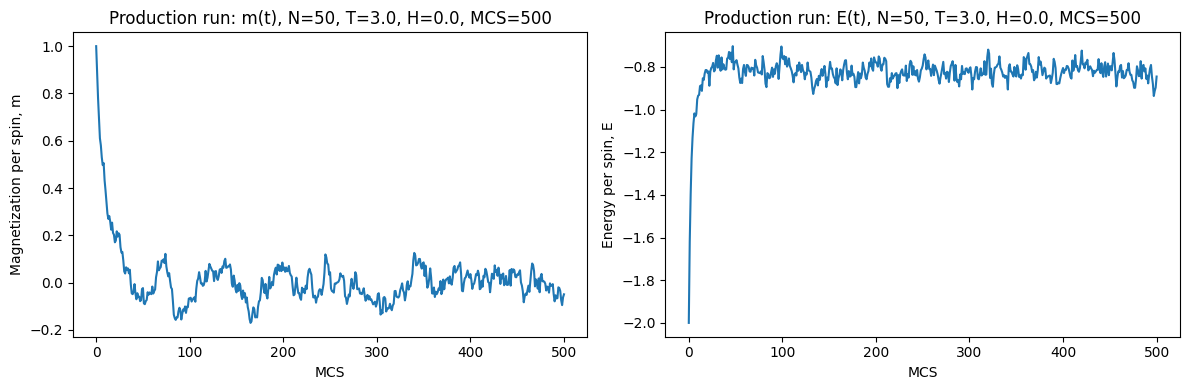

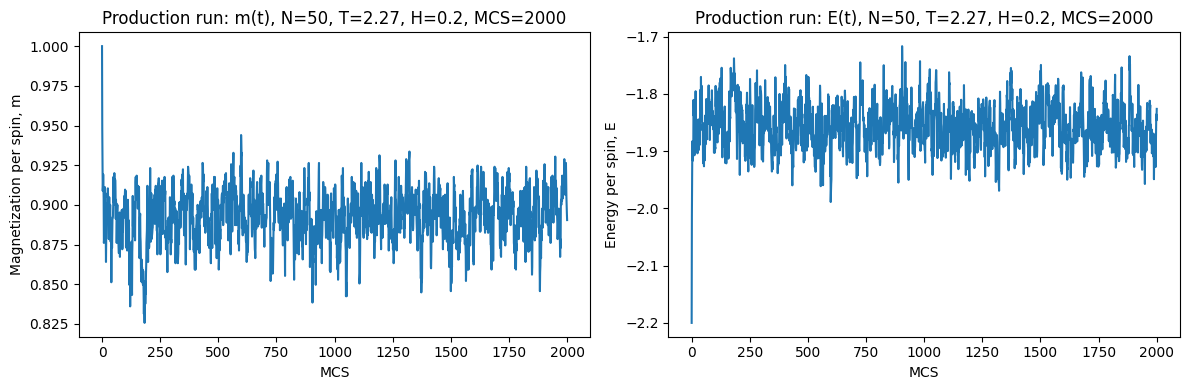

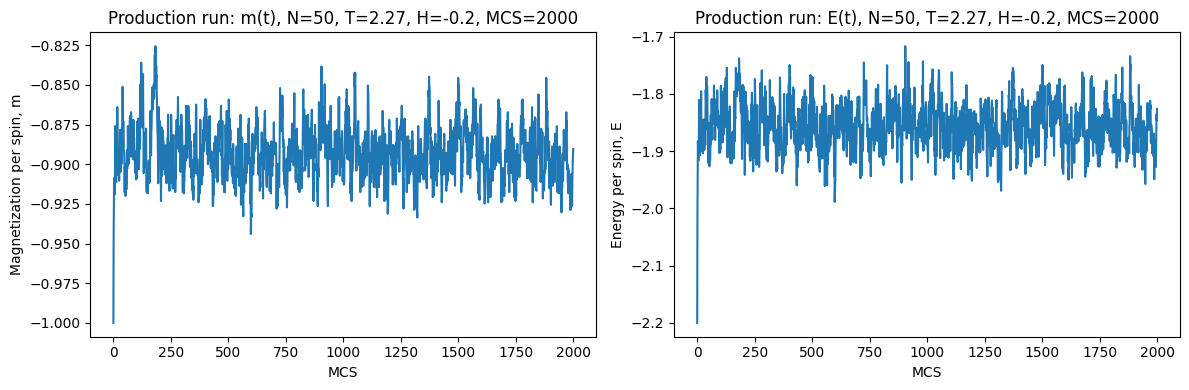

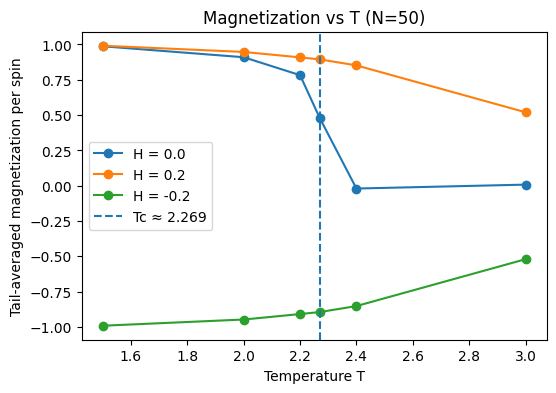

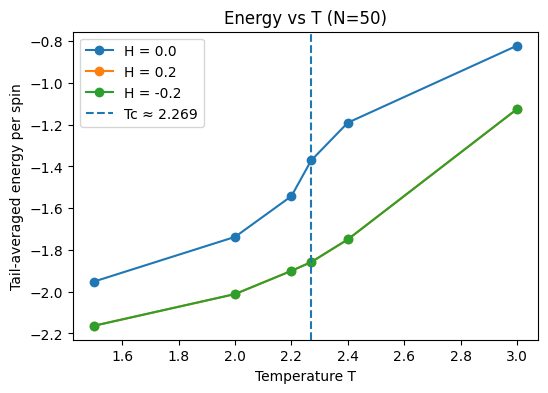


Tail-averaged equilibrium estimates (last 25% of each run):

H = 0.0
T        <m>_tail      std(m)       <E>_tail      std(E)
1.50       0.98667      0.00361     -1.95120      0.01220
2.00       0.90923      0.01394     -1.73733      0.03037
2.20       0.78235      0.05484     -1.54203      0.05562
2.27       0.47831      0.09804     -1.37116      0.05151
2.40      -0.01993      0.09699     -1.19013      0.04213
3.00       0.00778      0.03894     -0.82126      0.03628

H = 0.2
T        <m>_tail      std(m)       <E>_tail      std(E)
1.50       0.99065      0.00351     -2.16308      0.01288
2.00       0.94672      0.00854     -2.01139      0.02615
2.20       0.90813      0.01414     -1.90005      0.03698
2.27       0.89391      0.01630     -1.85821      0.04106
2.40       0.85152      0.02096     -1.74957      0.04733
3.00       0.51991      0.04236     -1.12528      0.05463

H = -0.2
T        <m>_tail      std(m)       <E>_tail      std(E)
1.50      -0.99065      0.00351     -2.16308

In [ ]:

import numpy as np;
import matplotlib.pyplot as plt;

# Ising helpers

def init_spins(N, ic = 'up', rng = None):
    if rng is None:
        rng = np.random.default_rng();

    if ic == 'up':
        return np.ones((N, N), dtype = np.int8);
    elif ic == 'down':
        return -np.ones((N, N), dtype = np.int8);
    elif ic == 'random':
        return rng.choice(np.array([-1, 1], dtype = np.int8), size = (N, N));
    else:
        raise ValueError("ic must be 'up', 'down', or 'random'");


def compute_magnetization(spins):
    return spins.mean();


def compute_energy(spins, H = 0.0):
    right = np.roll(spins, shift = -1, axis = 1);
    down  = np.roll(spins, shift = -1, axis = 0);
    E_total = -np.sum(spins * right) - np.sum(spins * down) - H * np.sum(spins);
    return E_total / spins.size;


def metropolis_sweep(spins, T, H = 0.0, rng = None):
    if rng is None:
        rng = np.random.default_rng();

    N = spins.shape[0];

    for _ in range(N * N):
        i = rng.integers(0, N);
        j = rng.integers(0, N);

        s = spins[i, j];
        nn_sum = (spins[(i - 1) % N, j] + spins[(i + 1) % N, j] + spins[i, (j - 1) % N] + spins[i, (j + 1) % N]);
        dE = 2.0 * s * (nn_sum + H);

        if dE <= 0.0 or rng.random() < np.exp(-dE / T):
            spins[i, j] = -s;
    # end for

def choose_initial_condition(H, mode = 'field_aligned'):
    if mode == 'random':
        return 'random';
    elif mode == 'up':
        return 'up';
    elif mode == 'field_aligned':
        if H > 0:
            return 'up';
        elif H < 0:
            return 'down';
        else:
            return 'up';
    else:
        raise ValueError("mode must be 'field_aligned', 'random', or 'up'");

# Use longer runs near the critical region where equilibration is slower
def choose_MCS(T, Tc):
    if abs(T - Tc) <= 0.08:
        return 2000;
    elif abs(T - Tc) <= 0.20:
        return 1000;
    else:
        return 500;


def run_ising(N, T, H = 0.0, MCS = 500, ic = 'up', seed = None, snapshot_times = None, return_snapshots = False):
    rng = np.random.default_rng(seed);
    spins = init_spins(N, ic = ic, rng = rng);

    m_series = np.zeros(MCS + 1);
    E_series = np.zeros(MCS + 1);

    m_series[0] = compute_magnetization(spins);
    E_series[0] = compute_energy(spins, H);

    snapshots = {};
    if return_snapshots:
        if snapshot_times is None:
            snapshot_times = [];
        if 0 in snapshot_times:
            snapshots[0] = spins.copy();

    for sweep in range(1, MCS + 1):
        metropolis_sweep(spins, T, H, rng = rng);
        m_series[sweep] = compute_magnetization(spins);
        E_series[sweep] = compute_energy(spins, H);

        if return_snapshots and (sweep in snapshot_times):
            snapshots[sweep] = spins.copy();
    # end for

    results = {'N': N, 'T': T, 'H': H, 'MCS': MCS, 'ic': ic, 'm_series': m_series, 'E_series': E_series, 'final_spins': spins.copy()};

    if return_snapshots:
        results['snapshots'] = snapshots;

    return results;


# Plotting helpers

def plot_time_series(results, title_prefix = ''):
    m = results['m_series'];
    E = results['E_series'];
    T = results['T'];
    H = results['H'];
    N = results['N'];
    MCS = results['MCS'];

    sweeps = np.arange(len(m));
    fig, axes = plt.subplots(1, 2, figsize = (12, 4));

    axes[0].plot(sweeps, m);
    axes[0].set_xlabel('MCS');
    axes[0].set_ylabel('Magnetization per spin, m');
    axes[0].set_title(f'{title_prefix} m(t), N = {N}, T = {T}, H = {H}, MCS = {MCS}');

    axes[1].plot(sweeps, E);
    axes[1].set_xlabel('MCS');
    axes[1].set_ylabel('Energy per spin, E');
    axes[1].set_title(f'{title_prefix} E(t), N = {N}, T = {T}, H = {H}, MCS = {MCS}');

    plt.tight_layout();
    plt.show();


def plot_snapshots(results, snapshot_times):
    snaps = results['snapshots'];
    n = len(snapshot_times);
    fig, axes = plt.subplots(1, n, figsize = (4*n, 4));

    if n == 1:
        axes = [axes];

    for ax, t in zip(axes, snapshot_times):
        if t in snaps:
            ax.imshow(snaps[t], cmap = 'bwr', vmin = -1, vmax = 1, origin = 'lower');
            ax.set_title(f'MCS = {t}');
            ax.set_xticks([]);
            ax.set_yticks([]);
        else:
            ax.axis('off');
    # end for

    plt.tight_layout();
    plt.show();


def tail_mean_std(series, frac = 0.25):
    n = len(series);
    start = int((1.0 - frac) * n);
    tail = series[start:];
    return tail.mean(), tail.std();


# Exact critical temperature
Tc = 2.0 / np.log(1.0 + np.sqrt(2.0));
print(f'Exact 2D Ising critical temperature Tc ≈ {Tc:.5f}');


# Small demo run
demo_N = 15;
demo_T = 2.20;
demo_H = 0.0;
demo_MCS = 100;
demo_ic = 'up';
demo_snapshot_times = [0, 1, 5, 10, 20, 50, 100];

demo_results = run_ising(N = demo_N, T = demo_T, H = demo_H, MCS = demo_MCS, ic = demo_ic, seed = 123,
                         snapshot_times = demo_snapshot_times, return_snapshots = True);

plot_snapshots(demo_results, demo_snapshot_times);


# Bigger lattice, graphics off, better equilibration.
prod_N = 50;
T_values = [1.5, 2.0, 2.2, 2.27, 2.4, 3.0];
H_values = [0.0, 0.2, -0.2];
all_results = {};

for H in H_values:
    ic = choose_initial_condition(H, mode = 'field_aligned');

    for T in T_values:
        MCS_here = choose_MCS(T, Tc);

        res = run_ising(N = prod_N, T = T, H = H, MCS = MCS_here, ic = ic, seed = 12345, return_snapshots = False);
        all_results[(T, H)] = res;
        m_tail, m_std = tail_mean_std(res['m_series'], frac = 0.25);
        E_tail, E_std = tail_mean_std(res['E_series'], frac = 0.25);

        print(f'N = {prod_N}, T = {T:.3f}, H = {H:.3f}, ic = {ic}, MCS = {MCS_here} | '
              f'final m = {res["m_series"][-1]:.4f}, final E = {res["E_series"][-1]:.4f} | '
              f'tail <m> = {m_tail:.4f}, tail <E> = {E_tail:.4f}');
    # end for
# end for


# Main plots
representative_cases = [#(1.5,  0.0),   # low T, H=0
                        (2.27, 0.0),   # near Tc, H=0
                        #(3.0,  0.0),   # high T, H=0
                        (2.27, 0.2),   # near Tc, positive field
                        (2.27,-0.2),   # near Tc, negative field
                        ];

for T, H in representative_cases:
    plot_time_series(all_results[(T, H)], title_prefix = 'Production run:');
# end for

# Summary plots using tail averages
plt.figure(figsize = (6, 4));
for H in H_values:
    m_tail_vals = [tail_mean_std(all_results[(T, H)]['m_series'], frac = 0.25)[0] for T in T_values];
    plt.plot(T_values, m_tail_vals, marker = 'o', label = f'H = {H}');
# end for
plt.axvline(Tc, linestyle = '--', label = f'Tc ≈ {Tc:.3f}');
plt.xlabel('Temperature T');
plt.ylabel('Tail-averaged magnetization per spin');
plt.title(f'Magnetization vs T (N={prod_N})');
plt.legend();
plt.show();

plt.figure(figsize = (6, 4));
for H in H_values:
    E_tail_vals = [tail_mean_std(all_results[(T, H)]['E_series'], frac = 0.25)[0] for T in T_values];
    plt.plot(T_values, E_tail_vals, marker = 'o', label = f'H = {H}');
#end for
plt.axvline(Tc, linestyle = '--', label = f'Tc ≈ {Tc:.3f}');
plt.xlabel('Temperature T');
plt.ylabel('Tail-averaged energy per spin');
plt.title(f'Energy vs T (N = {prod_N})');
plt.legend();
plt.show();

# Summary
print('\nTail-averaged equilibrium estimates (last 25% of each run):');
for H in H_values:
    print(f'\nH = {H}');
    print('T        <m>_tail      std(m)       <E>_tail      std(E)');
    for T in T_values:
        m_mean, m_std = tail_mean_std(all_results[(T, H)]['m_series'], frac = 0.25);
        E_mean, E_std = tail_mean_std(all_results[(T, H)]['E_series'], frac = 0.25);
        print(f'{T:4.2f}    {m_mean:10.5f}   {m_std:10.5f}   {E_mean:10.5f}   {E_std:10.5f}');
    # end for
# end for

# EOF



Exact 2D Ising critical temperature Tc ≈ 2.26919
T=2.000 | <m>=0.91604 ± 0.00051 | <E>=-1.76281 ± 0.00111
T=2.100 | <m>=0.86679 ± 0.00079 | <E>=-1.66750 ± 0.00121
T=2.150 | <m>=0.84874 ± 0.00087 | <E>=-1.62970 ± 0.00142
T=2.200 | <m>=0.81242 ± 0.00119 | <E>=-1.57242 ± 0.00155
T=2.240 | <m>=0.76437 ± 0.00155 | <E>=-1.52172 ± 0.00159
T=2.270 | <m>=0.74368 ± 0.00129 | <E>=-1.48068 ± 0.00146
T=2.300 | <m>=0.65353 ± 0.00260 | <E>=-1.41384 ± 0.00204
T=2.350 | <m>=0.64127 ± 0.00269 | <E>=-1.37382 ± 0.00192
T=2.400 | <m>=0.46586 ± 0.00256 | <E>=-1.26671 ± 0.00172
T=2.500 | <m>=0.12409 ± 0.00621 | <E>=-1.11376 ± 0.00148


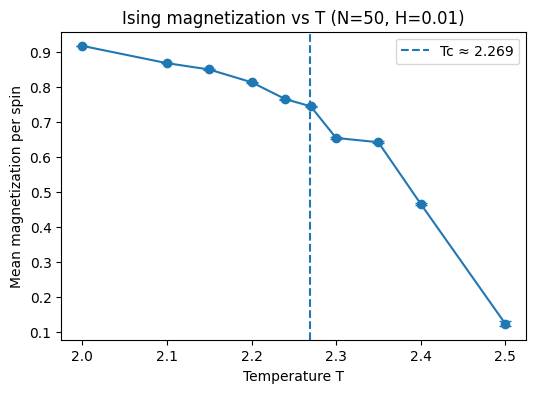

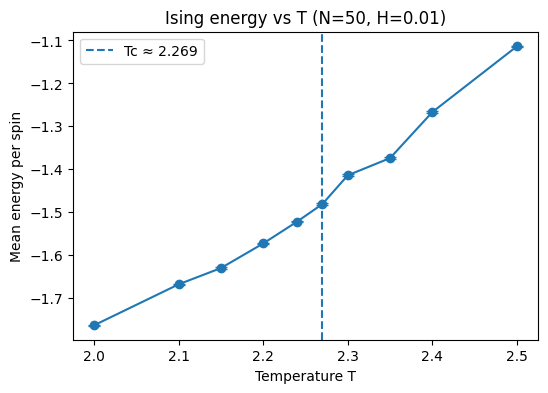

In [ ]:

import numpy as np;
import matplotlib.pyplot as plt;

# Ising helpers

def init_spins(N, ic = 'up', rng = None):
    if rng is None:
        rng = np.random.default_rng();

    if ic == 'up':
        return np.ones((N, N), dtype = np.int8);
    elif ic == 'down':
        return -np.ones((N, N), dtype = np.int8);
    elif ic == 'random':
        return rng.choice(np.array([-1, 1], dtype = np.int8), size = (N, N));
    else:
        raise ValueError("ic must be 'up', 'down', or 'random'");


def compute_magnetization(spins):
    return spins.mean();


def compute_energy(spins, H = 0.0):
    right = np.roll(spins, shift = -1, axis = 1);
    down  = np.roll(spins, shift = -1, axis = 0);
    E_total = -np.sum(spins * right) - np.sum(spins * down) - H * np.sum(spins);
    return E_total / spins.size;


def metropolis_sweep(spins, T, H = 0.0, rng = None):
    if rng is None:
        rng = np.random.default_rng();

    N = spins.shape[0];
    for _ in range(N * N):
        i = rng.integers(0, N);
        j = rng.integers(0, N);
        s = spins[i, j];
        nn_sum = (spins[(i - 1) % N, j] + spins[(i + 1) % N, j] + spins[i, (j - 1) % N] + spins[i, (j + 1) % N]);
        dE = 2.0 * s * (nn_sum + H);

        if dE <= 0.0 or rng.random() < np.exp(-dE / T):
            spins[i, j] = -s;
    # end for

# Task 2 bit

# Run Ising simulation, discard an initial transient, then measure m and E over the next measure_MCS sweeps
def run_ising_with_transient(N, T, H = 0.0, transient_MCS = 500, measure_MCS = 1000, ic = 'up', seed = None):
    rng = np.random.default_rng(seed);
    spins = init_spins(N, ic = ic, rng = rng);

    # Burn-in / transient
    for _ in range(transient_MCS):
        metropolis_sweep(spins, T, H, rng = rng);
    # end for
    # Measurement stage
    m_samples = np.zeros(measure_MCS);
    E_samples = np.zeros(measure_MCS);

    for s in range(measure_MCS):
        metropolis_sweep(spins, T, H, rng = rng);
        m_samples[s] = compute_magnetization(spins);
        E_samples[s] = compute_energy(spins, H);
    # end for
    m_mean = np.mean(m_samples);
    E_mean = np.mean(E_samples);

    # standard errors of the means
    m_sem = np.std(m_samples, ddof = 1) / np.sqrt(measure_MCS);
    E_sem = np.std(E_samples, ddof = 1) / np.sqrt(measure_MCS);

    return {'T': T, 'H': H, 'N': N, 'transient_MCS': transient_MCS, 'measure_MCS': measure_MCS, 'm_mean': m_mean, 'm_sem': m_sem,
            'E_mean': E_mean,'E_sem': E_sem, 'm_samples': m_samples, 'E_samples': E_samples}


# Parameters

Tc = 2.0 / np.log(1.0 + np.sqrt(2.0));
print(f'Exact 2D Ising critical temperature Tc ≈ {Tc:.5f}');

N = 50;
H_small = 0.01;          # very small positive field, H = 0+
transient_MCS = 1000;    # chosen from Task 1: near Tc convergence is slow
measure_MCS = 1000;      # measurement duration after transient
ic = 'up';
# Temperatures around Tc
T_values = np.array([2.00, 2.10, 2.15, 2.20, 2.24, 2.27, 2.30, 2.35, 2.40, 2.50]);
# Run temperature scan
results_Tscan = [];

for k, T in enumerate(T_values):
    res = run_ising_with_transient(N = N, T = T, H = H_small, transient_MCS = transient_MCS,
                                   measure_MCS = measure_MCS, ic = ic, seed = 12345 + k);
    results_Tscan.append(res);

    print(f'T = {T:.3f} | <m> = {res["m_mean"]:.5f} ± {res["m_sem"]:.5f} | ' f'<E> = {res["E_mean"]:.5f} ± {res["E_sem"]:.5f}');
# end for

# Convert to arrays
m_means = np.array([r['m_mean'] for r in results_Tscan]);
m_sems  = np.array([r['m_sem']  for r in results_Tscan]);
E_means = np.array([r['E_mean'] for r in results_Tscan]);
E_sems  = np.array([r['E_sem']  for r in results_Tscan]);

# Plots

plt.figure(figsize = (6, 4));
plt.errorbar(T_values, m_means, yerr = m_sems, fmt = 'o-', capsize = 4);
plt.axvline(Tc, linestyle = '--', label = f'Tc ≈ {Tc:.3f}');
plt.xlabel('Temperature T');
plt.ylabel('Mean magnetization per spin');
plt.title(f'Ising magnetization vs T (N = {N}, H = {H_small})');
plt.legend();
plt.show();

plt.figure(figsize = (6, 4));
plt.errorbar(T_values, E_means, yerr = E_sems, fmt = 'o-', capsize = 4);
plt.axvline(Tc, linestyle = '--', label = f'Tc ≈ {Tc:.3f}');
plt.xlabel('Temperature T');
plt.ylabel('Mean energy per spin');
plt.title(f'Ising energy vs T (N = {N}, H = {H_small})');
plt.legend();
plt.show();

# EOF

